### Compas Analysis 

#### Step 1. Loading data 


In this step, we load the COMPAS dataset from an online source using pandas.  
This dataset contains criminal defendant information and is commonly used for fairness analysis in machine learning.

We first import the necessary library, then read the dataset from a URL into a pandas DataFrame.  
Finally, we check the shape of the dataset to understand how many observations (rows) and variables (columns) are included.

In [5]:
import pandas as pd # Import pandas library for data manipulation and analysis
# Define the URL where the dataset is stored
# This dataset is from github/ProPublica 
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
# Read the CSV file from the URL into a pandas DataFrame
# The DataFrame 'raw_data' will store all the original data
raw_data = pd.read_csv(url)
# Print the shape of the dataset (rows, columns)
# This helps us understand the size of the dataset
print(raw_data.shape)

(7214, 53)


Observing the result above, we can know that this data has 7214 raws with 53 columns.

#### Step 2 Data Preview


In this step, we display the first 10 rows of the dataset using `df.head(10)` to gain an initial understanding of the data.

This allows us to:
- Inspect the structure and layout of the dataset
- Identify the available variables and their meanings (e.g., age, race, priors_count)
- Check whether the data has been loaded correctly
- Get a sense of the data types (categorical vs numerical)

Previewing the data is an important first step in any data analysis workflow, as it helps us understand what kind of preprocessing and feature engineering may be needed in the following steps.

In [6]:
# Show the first 10 rows of the dataset
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


#### Step 3 Data Preprocessing and Feature Engineering



In this step, we clean and preprocess the dataset to prepare it for analysis and modeling.

First, we select only the relevant variables from the raw dataset to focus on meaningful features.  
Then, we apply several filtering conditions to remove invalid or irrelevant observations, such as missing values,and undefined categories.

Next, we convert variables into appropriate data types.

Finally, we create new derived variables (feature engineering), including categorical factors with specified reference levels. These transformations are important for statistical modeling, especially when interpreting regression coefficients.

Overall, this step ensures that the dataset is clean, consistent, and suitable for further analysis.

In [7]:
import pandas as pd
# Define groups of variables for later type conversion
# numeric_vars: variables that should remain numeric
# datetime_vars: variables that represent timestamps
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

# Select only relevant columns from the raw dataset
# This helps reduce noise and focus on variables used in analysis
df = raw_data[
    [
        "age",
        "c_charge_degree",
        "race",
        "age_cat",
        "score_text",
        "sex",
        "priors_count",
        "days_b_screening_arrest",
        "decile_score",
        "is_recid",
        "two_year_recid",
        "c_jail_in",
        "c_jail_out",
    ]
].copy()

# -------------------------------
# Data Filtering 
# -------------------------------


# Keep only observations where screening arrest happens within [-30, 30] days
df = df[
    df["days_b_screening_arrest"].between(-30, 30)
]
# Remove rows with invalid recidivism values (-1 means missing/undefined)
df = df[df["is_recid"] != -1]
# Remove observations with charge degree "O" (unclassified/other)
df = df[df["c_charge_degree"] != "O"]
# Remove rows with missing COMPAS score
df = df[df["score_text"] != "N/A"]

# -------------------------------
# Type Conversion
# -------------------------------


# Convert datetime columns into proper datetime format
# errors="coerce" will turn invalid parsing into NaT (missing datetime)
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True, errors="coerce")

# Convert all non-numeric and non-datetime columns into categorical variables
# This is important for modeling and memory efficiency
categorical_cols = [col for col in df.columns if col not in numeric_vars + datetime_vars]
for col in categorical_cols:
    df[col] = df[col].astype("category")

# -------------------------------
# Feature Engineering
# -------------------------------

# Create a categorical version of charge degree
df["crime_factor"] = df["c_charge_degree"].astype("category")

# Create age categories with a defined reference group ("25 - 45")
# The first category will act as baseline in modeling
df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45", "Less than 25", "Greater than 45"],
    ordered=False
)
# Define race categories with "Caucasian" as the reference group (first position)
# We dynamically extract all unique race values from the dataset (excluding NaN),
# and then prepend "Caucasian" to ensure it is used as the baseline in modeling.

# This approach is more flexible than hardcoding all categories, because:
# - It automatically adapts to the dataset if new or unexpected race values appear
# - It avoids accidentally omitting valid categories

# If categories are manually hardcoded and do not include all possible values,
# any unmatched values will be converted to NaN when creating the categorical variable.
# This may silently lead to data loss or biased results if not handled properly.

df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian"] + [x for x in df["race"].dropna().unique() if x != "Caucasian"],
    ordered=False
)
df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian"] + [x for x in df["race"].dropna().unique() if x != "Caucasian"],
    ordered=False
)

# gender_factor: match Female / Male labels, with Male as reference
# assuming original sex values are Female and Male
df["gender_factor"] = pd.Categorical(
    df["sex"].replace({"Female": "Female", "Male": "Male"}),
    categories=["Male", "Female"],
    ordered=False
)

# Create binary score variable:
# Low -> LowScore
# Medium/High -> HighScore
df["score_factor"] = pd.Categorical
df["score_factor"] = pd.Categorical(
    # We use .ne("Low") to create a boolean mask where "Low" becomes False and others become True
    df["score_text"].ne("Low").map({False: "LowScore", True: "HighScore"}),
    categories=["LowScore", "HighScore"],
    ordered=False
)

# Number of rows
print(len(df))


6172



After applying the filtering conditions, the number of observations is reduced to 6,172 from the original dataset.

This reduction indicates that a portion of the data has been removed due to:
- Missing or undefined values (e.g., is_recid = -1, score_text = "N/A")
- Irrelevant or out-of-scope observations (e.g., c_charge_degree = "O")
- Observations outside the specified screening window (±30 days)

These filtering steps are necessary to ensure data quality and consistency. 

#### Step 4 Filtered Data Preview

After applying the filtering and preprocessing steps, we display the first few rows of the cleaned dataset using df.head().This step serves as a quick check before proceeding to further analysit.

In [8]:
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n


We use `df.info()` to quickly check the structure of the dataset.  
From the output, we can see that the data types have been correctly converted (e.g., categorical and datetime), and there are no missing values in the selected variables. This confirms that the dataset is clean and ready for further analysis.

#### Step 0  Set up and import  (assign3 start)


In [10]:
# define and create a binary variable "high_risk" where 1 indicates "Medium" or "High" risk, and 0 indicates "Low" risk
df["high_risk"] = (df["score_text"] != "Low").astype(int)

In [11]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

# Load and clean COMPAS data (Lecture 01 pipeline)

print(f"N = {len(df):,}")
print(df[['race','sex','high_risk','two_year_recid']].head())

N = 6,172
               race   sex  high_risk two_year_recid
0             Other  Male          0              0
1  African-American  Male          0              1
2  African-American  Male          0              1
5             Other  Male          0              0
6         Caucasian  Male          1              1


The dataset contains 6,172 observations after preprocessing.
We first take a quick look at key variables like race, sex, the predicted risk (high_risk), and the actual outcome (two_year_recid) to make sure everything is set up correctly for the fairness analysis.

Here, high_risk represents the model’s prediction, while two_year_recid reflects what actually happened. These two variables will be used later to evaluate how the model performs across different groups, especially in terms of errors like false positives and false negatives.

#### Question 1 AIR & Marginal Effect and SMD by race

In [ ]:
#AIR & ME by race 
def selection_rate(df, group_col, outcome_col, ref_group):
  """Selection rates, AIR, and ME relative to reference group"""
  rates = (df.groupby(group_col)[outcome_col].mean().rename('selection_rate').reset_index())
  ref_rate = rates.loc[rates[group_col]==ref_group, 'selection_rate'].values[0]
  rates['AIR'] = rates['selection_rate'] / ref_rate
  rates['ME'] = rates['selection_rate'] - ref_rate
  rates['flag_80'] = rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')
  return rates
sir = selection_rate(df, 'race', 'high_risk', ref_group='Caucasian')
print(sir.sort_values('AIR').to_string(index=False))

            race  selection_rate      AIR        ME        flag_80
           Other        0.204082 0.616643 -0.126874 *** BELOW 0.80
           Asian        0.225806 0.682286 -0.105149 *** BELOW 0.80
        Hispanic        0.277014 0.837011 -0.053942               
       Caucasian        0.330956 1.000000  0.000000               
African-American        0.576063 1.740604  0.245107               
 Native American        0.727273 2.197492  0.396317               


/var/folders/7l/_y07h61n1zv1497x7brlcs9m0000gn/T/ipykernel_60371/771092383.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = (df.groupby(group_col)[outcome_col].mean().rename('selection_rate').reset_index())


AIR = group_rate / ref_rate , if the group rate of high risking is higher than the reference group , AIR will be higher 

ME = group_rate - ref_rate

The results show substantial differences in selection rates across racial groups. African-American and Native American individuals are significantly more likely to be classified as high risk compared to Caucasians, with AIR values of 1.74 and 2.20, respectively.

In contrast, Asian and Other groups have AIR values below 0.80, which may indicate potential disparities under the 80% rule.

These findings suggest that the model produces unequal outcomes across groups. However, it is important to note that differences in selection rates alone do not necessarily imply bias, as they may also reflect underlying differences in recidivism rates across groups.

In [10]:
# SMD on continuous COMPAS decile score
def smd(df, group_col, score_col, ref_group):
    ref = df.loc[df[group_col] == ref_group, score_col]
    results = []

    for grp, g in df.groupby(group_col):
        if grp == ref_group:
            continue

        sc = g[score_col]
        pooled = np.sqrt((ref.var() + sc.var()) / 2)
        d = (sc.mean() - ref.mean()) / pooled if pooled > 0 else 0

        mag = (
            'small' if abs(d) < 0.2 else
            'medium' if abs(d) < 0.5 else
            'large' if abs(d) < 0.8 else
            'very large'
        )

        results.append({
            group_col: grp,
            'mean_score': round(sc.mean(), 3),
            'SMD': round(d, 3),
            'magnitude': mag
        })

    return pd.DataFrame(results)
smd_tbl = smd(df, 'race', 'decile_score', ref_group='Caucasian')
print(smd_tbl.sort_values('SMD', ascending=False).to_string(index=False))

            race  mean_score    SMD  magnitude
 Native American       6.455  1.008 very large
African-American       5.277  0.608      large
        Hispanic       3.383 -0.099      small
           Other       2.889 -0.304     medium
           Asian       2.839 -0.310     medium


/var/folders/7l/_y07h61n1zv1497x7brlcs9m0000gn/T/ipykernel_60371/2873220320.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp, g in df.groupby(group_col):


SMD compares how much each group’s average risk score differs from the reference group (Caucasian).

A positive SMD means the group receives higher average risk scores, while a negative SMD means lower average scores.

This reflects differences in how the model assigns scores across groups, not differences in error rates.

Large differences suggest that disparities in outcomes may be driven by differences in score distributions. However, these differences do not necessarily imply unfairness, as they may also reflect underlying differences in the data.

#### Question 1 AIR & Marginal Effect and SMD by sex

In [ ]:
#AIR & ME by sex
def selection_rate(df, group_col, outcome_col, ref_group):
  """Selection rates, AIR, and ME relative to reference group"""
  rates = (df.groupby(group_col)[outcome_col].mean().rename('selection_rate').reset_index())
  ref_rate = rates.loc[rates[group_col]==ref_group, 'selection_rate'].values[0]
  rates['AIR'] = rates['selection_rate'] / ref_rate
  rates['ME'] = rates['selection_rate'] - ref_rate
  rates['flag_80'] = rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')
  return rates
sir = selection_rate(df, 'sex', 'high_risk', ref_group='Male')
print(sir.sort_values('AIR').to_string(index=False))

   sex  selection_rate      AIR        ME flag_80
Female        0.405106 0.889809 -0.050167        
  Male        0.455273 1.000000  0.000000        


/var/folders/7l/_y07h61n1zv1497x7brlcs9m0000gn/T/ipykernel_60371/3382431340.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = (df.groupby(group_col)[outcome_col].mean().rename('selection_rate').reset_index())


We compare selection rates across gender using Male as the reference group.

The results show that the selection rate for males is 0.455, while for females it is slightly lower at 0.405. This leads to an Adverse Impact Ratio (AIR) of 0.89 for females relative to males.

The negative marginal effect (ME = -0.05) suggests that females are selected at a slightly lower rate compared to males.

Overall, while there is a small disparity, it is not large enough to raise immediate legal concern, though it may still warrant further monitoring.


In [13]:
# SMD by sex 
def smd(df, group_col, score_col, ref_group):
    ref = df.loc[df[group_col] == ref_group, score_col]
    results = []

    for grp, g in df.groupby(group_col):
        if grp == ref_group:
            continue

        sc = g[score_col]
        pooled = np.sqrt((ref.var() + sc.var()) / 2)
        d = (sc.mean() - ref.mean()) / pooled if pooled > 0 else 0

        mag = (
            'small' if abs(d) < 0.2 else
            'medium' if abs(d) < 0.5 else
            'large' if abs(d) < 0.8 else
            'very large'
        )

        results.append({
            group_col: grp,
            'mean_score': round(sc.mean(), 3),
            'SMD': round(d, 3),
            'magnitude': mag
        })

    return pd.DataFrame(results)
smd_tbl = smd(df, 'sex', 'decile_score', ref_group='Male')
print(smd_tbl.sort_values('SMD', ascending=False).to_string(index=False))

   sex  mean_score    SMD magnitude
Female       4.064 -0.158     small


/var/folders/7l/_y07h61n1zv1497x7brlcs9m0000gn/T/ipykernel_60371/291028565.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp, g in df.groupby(group_col):


The average predicted risk score for females is slightly lower than that of the reference group (males), with an SMD of -0.158. This difference is categorized as small, indicating that the distribution of predicted risk scores is fairly similar across genders. Therefore, there is no strong evidence of systematic disparity in model scores between males and females.


#### Question 2 Intersectional Analysis  (race × sex)

In [18]:
# Intersectional analysis -- race x sex
df['subgroup'] = df['race'].astype(str) + ' / ' + df['sex'].astype(str)
# Keep subgroups with n >= 30
counts = df['subgroup'].value_counts()
valid_sg = counts[counts >= 30].index
df_sub = df[df['subgroup'].isin(valid_sg)].copy()
sub_rates = (df_sub.groupby('subgroup')['high_risk'].agg(['mean','count']).rename(columns={'mean':'selection_rate','count':'n'}).reset_index())
ref_rate = sub_rates.loc[sub_rates['subgroup']=='Caucasian / Male','selection_rate'].values[0]
sub_rates['AIR'] = sub_rates['selection_rate'] / ref_rate
sub_rates['flag'] = sub_rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')
print(sub_rates.sort_values('AIR').to_string(index=False))
worst = sub_rates.loc[sub_rates['AIR'].idxmin()]
print(f"\nWorst: {worst['subgroup']}, AIR={worst['AIR']:.3f} and "
f"n={worst['n']}")

                 subgroup  selection_rate    n      AIR           flag
        Hispanic / Female        0.085366   82 0.270270 *** BELOW 0.80
           Other / Female        0.189655   58 0.600451 *** BELOW 0.80
             Other / Male        0.207018  285 0.655421 *** BELOW 0.80
          Hispanic / Male        0.313817  427 0.993551               
         Caucasian / Male        0.315854 1621 1.000000               
       Caucasian / Female        0.381743  482 1.208603               
African-American / Female        0.495446  549 1.568591               
  African-American / Male        0.592917 2626 1.877184               

Worst: Hispanic / Female, AIR=0.270 and n=82


The intersectional analysis examines disparities across combined demographic groups defined by both race and sex. The results show that disparities are more pronounced when considering these intersections.

In particular, Hispanic females have the lowest selection rate, with an AIR of 0.270 relative to Caucasian males, indicating a substantial disparity under the 80% rule.

On the other hand, African-American males and females have significantly higher selection rates, with AIR values above 1.5.

These findings highlight that fairness issues may not be fully captured when analyzing race or sex independently. Instead, intersectional analysis reveals more nuanced patterns of disparity, identifying subgroups that are particularly disadvantaged or advantaged by the model.

#### Question 3 Error-Rate Disparity Analysis by race 

In [15]:
# FPR and FNR by race
def error_rates(df, group_col, pred_col, outcome_col):
    results = []

    for grp, g in df.groupby(group_col):
        tp = ((g[pred_col] == 1) & (g[outcome_col] == 1)).sum()
        tn = ((g[pred_col] == 0) & (g[outcome_col] == 0)).sum()
        fp = ((g[pred_col] == 1) & (g[outcome_col] == 0)).sum()
        fn = ((g[pred_col] == 0) & (g[outcome_col] == 1)).sum()

        results.append({
            group_col: grp,
            'n': len(g),
            'FPR': fp / (fp + tn) if (fp + tn) > 0 else float('nan'),
            'FNR': fn / (fn + tp) if (fn + tp) > 0 else float('nan'),
            'Acc': (tp + tn) / len(g)
        })

    return pd.DataFrame(results)

er = error_rates(df, 'race', 'high_risk', 'two_year_recid')
print(er.sort_values('FPR', ascending=False).to_string(index=False))

# Highlight Black vs. White disparity
for grp in ['African-American', 'Caucasian']:
    row = er.loc[er['race'] == grp]
    print(f"{grp}: FPR={row['FPR'].values[0]:.3f}, FNR={row['FNR'].values[0]:.3f}")

            race    n      FPR      FNR      Acc
 Native American   11 0.500000 0.000000 0.727273
African-American 3175 0.423382 0.284768 0.649134
       Caucasian 2103 0.220141 0.496350 0.671897
        Hispanic  509 0.193750 0.582011 0.662083
           Other  343 0.127854 0.661290 0.679300
           Asian   31 0.086957 0.375000 0.838710
African-American: FPR=0.423, FNR=0.285
Caucasian: FPR=0.220, FNR=0.496


/var/folders/7l/_y07h61n1zv1497x7brlcs9m0000gn/T/ipykernel_60371/2114344559.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp, g in df.groupby(group_col):


The model makes different types of mistakes across groups. African-American individuals are more likely to be falsely labeled as high risk, while Caucasians are more likely to be falsely labeled as low risk. This imbalance in error types suggests that the model may treat groups differently, which raises potential fairness concerns.


#### Question 3 Z-test 

In [11]:
# Two-proportion z-test: Black vs. White
groups = ['African-American', 'Caucasian']
ns = df[df['race'].isin(groups)].groupby('race')['high_risk'].count()
events = df[df['race'].isin(groups)].groupby('race')['high_risk'].sum()
stat, pval = proportions_ztest(events[groups].values, ns[groups].values)
print(f"\nAIR test: z = {stat:.3f}, p = {pval:.4f}")


AIR test: z = 17.452, p = 0.0000


/var/folders/7l/_y07h61n1zv1497x7brlcs9m0000gn/T/ipykernel_14474/3437248538.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ns = df[df['race'].isin(groups)].groupby('race')['high_risk'].count()
/var/folders/7l/_y07h61n1zv1497x7brlcs9m0000gn/T/ipykernel_14474/3437248538.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  events = df[df['race'].isin(groups)].groupby('race')['high_risk'].sum()


A two-proportion z-test was conducted to compare the selection rates between African-American and Caucasian individuals. The results show a highly significant difference (z = 17.452, p < 0.001), indicating that the difference in selection rates is unlikely to be due to random variation.

This suggests that African-American individuals are significantly more likely to be classified as high risk compared to Caucasians. However, this result alone does not imply that the model is biased, as the observed difference may also reflect underlying differences in recidivism rates between groups.

#### Question 4 bar chart of FPR and FNR by race

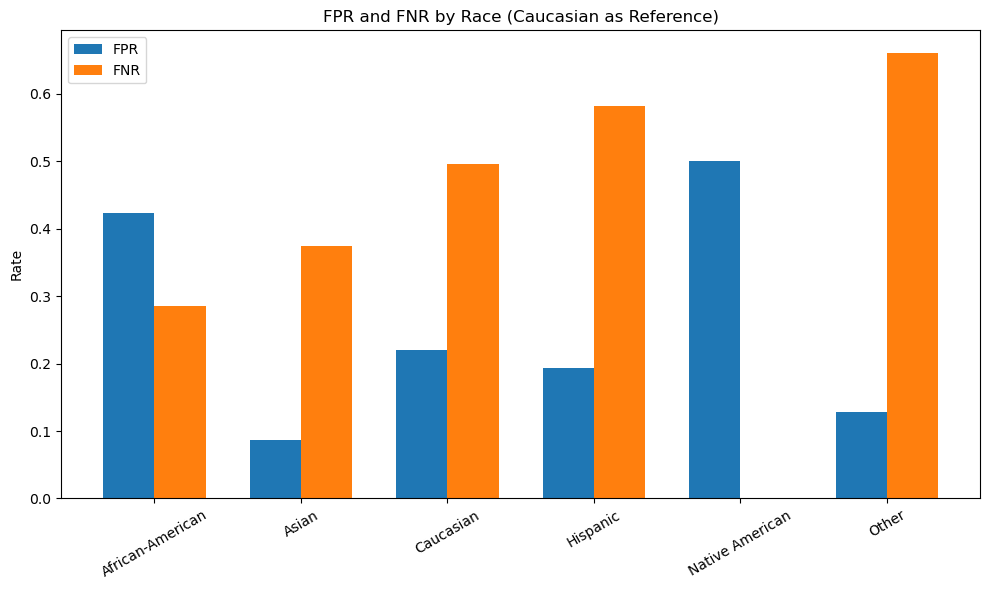

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# x axis
groups = er['race']
x = np.arange(len(groups))
width = 0.35

plt.figure(figsize=(10,6))

# FPR
plt.bar(x - width/2, er['FPR'], width, label='FPR')

# FNR
plt.bar(x + width/2, er['FNR'], width, label='FNR')

plt.xticks(x, groups, rotation=30)
plt.ylabel('Rate')
plt.title('FPR and FNR by Race (Caucasian as Reference)')
plt.legend()
plt.tight_layout()
plt.show()

The grouped bar chart shows clear disparities in error rates across racial groups. African-American and Native American individuals exhibit relatively high false positive rates (FPR), indicating they are more likely to be incorrectly classified as high risk. In contrast, Caucasian and other groups tend to have higher false negative rates (FNR), meaning they are more likely to be incorrectly classified as low risk.

This pattern suggests that the model distributes errors unevenly across groups, raising fairness concerns and indicating a violation of equalized odds.

#### Compliance memo  


This memo summarizes the results of a fairness analysis conducted on the COMPAS recidivism risk model using multiple evaluation metrics, including Adverse Impact Ratio (AIR), Marginal Effect (ME), Standardized Mean Difference (SMD), false positive rate (FPR), false negative rate (FNR), and a two-proportion z-test.

First, outcome-based analysis shows clear disparities in selection rates across racial groups. Using Caucasian individuals as the reference group, the AIR for Asian and Other groups falls below the 0.80 threshold, suggesting potential disparate impact under the EEOC 80% rule. In contrast, African-American and Native American individuals have much higher selection rates. The z-test comparing Black and White groups is highly significant (z = 17.452, p < 0.001), indicating that these differences are unlikely to be due to random chance.

Second, error-rate analysis reveals that the model makes different types of mistakes across groups. African-American individuals have a higher false positive rate (FPR), meaning they are more likely to be incorrectly classified as high risk. On the other hand, Hispanic and Other groups show higher false negative rates (FNR), meaning they are more likely to be incorrectly classified as low risk. This suggests that the model does not satisfy equalized odds and distributes errors unevenly across groups.

Third, score-based analysis (SMD) indicates that African-American and Native American individuals tend to receive higher risk scores on average, while Asian, Hispanic, and Other groups receive lower scores compared to the reference group. Additionally, intersectional analysis shows that Hispanic females experience the lowest selection rate (AIR = 0.270), highlighting that disparities can be even more pronounced at the subgroup level.

Overall, these findings raise important fairness concerns. However, it is important to note that each metric captures different aspects of fairness. AIR reflects selection disparities but not error types, while SMD reflects score differences rather than causal bias. Additionally, some subgroup sample sizes are relatively small, which may affect the reliability of the results. Therefore, further investigation and potential model adjustments are recommended before deployment.